In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df.shape
df.dtypes
df.isnull().sum() #No NULLS
df.duplicated().sum()

df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], inplace=True)

df['Attrition_Flag'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

**Overall Attrition Rate**

In [7]:
attrition_rate = df['Attrition_Flag'].mean() * 100
print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

Overall Attrition Rate: 16.12%


**Department Attrition Rate**

In [9]:
dept_attrition = df.groupby('Department')['Attrition_Flag'].mean() * 100
print(dept_attrition)

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition_Flag, dtype: float64


**Attrition by Age**

In [8]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,25,35,45,60],labels=['18-25','26-35','36-45','46-60'])
age_attrition = df.groupby('AgeGroup')['Attrition_Flag'].mean() * 100
print(age_attrition)

AgeGroup
18-25    34.782609
26-35    19.141914
36-45     9.188034
46-60    12.454212
Name: Attrition_Flag, dtype: float64


/tmp/ipykernel_1399/242835482.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_attrition = df.groupby('AgeGroup')['Attrition_Flag'].mean() * 100


**Attrition by Salary**

In [10]:
df['SalaryBand'] = pd.cut(df['MonthlyIncome'], bins=[0,3000,6000,10000,20000], labels=['Low','Medium','High','Very High'])
salary_attrition = df.groupby('SalaryBand')['Attrition_Flag'].mean() * 100
print(salary_attrition)

SalaryBand
Low          28.607595
Medium       12.716763
High         12.000000
Very High     8.896797
Name: Attrition_Flag, dtype: float64


/tmp/ipykernel_1399/658751224.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_attrition = df.groupby('SalaryBand')['Attrition_Flag'].mean() * 100


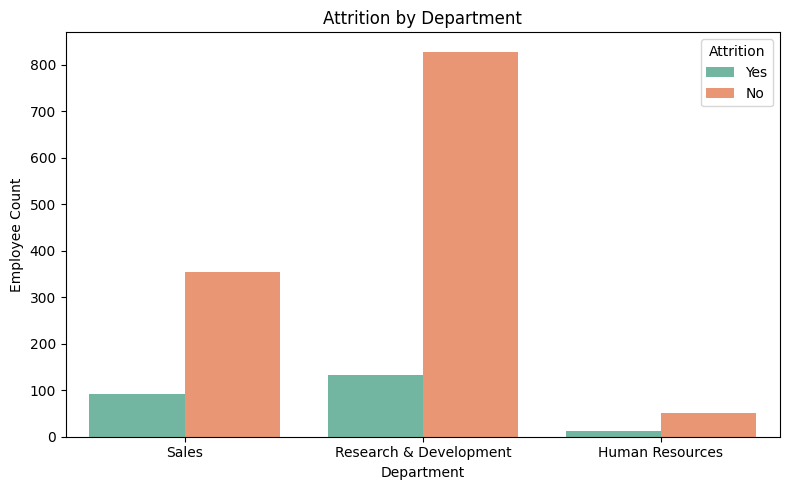

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Department', hue='Attrition', palette='Set2')
plt.title('Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Employee Count')
plt.tight_layout()
plt.savefig('attrition_dept.png', dpi=150)
plt.show()

/tmp/ipykernel_1399/807679587.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set1')


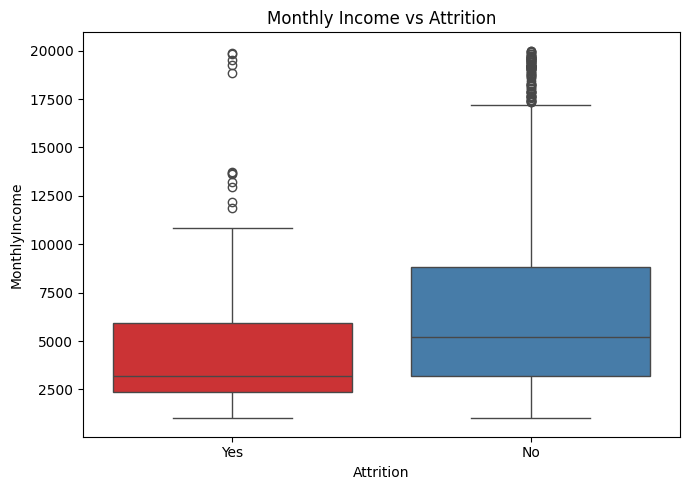

In [12]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set1')
plt.title('Monthly Income vs Attrition')
plt.tight_layout()
plt.savefig('income_attrition.png', dpi=150)
plt.show()

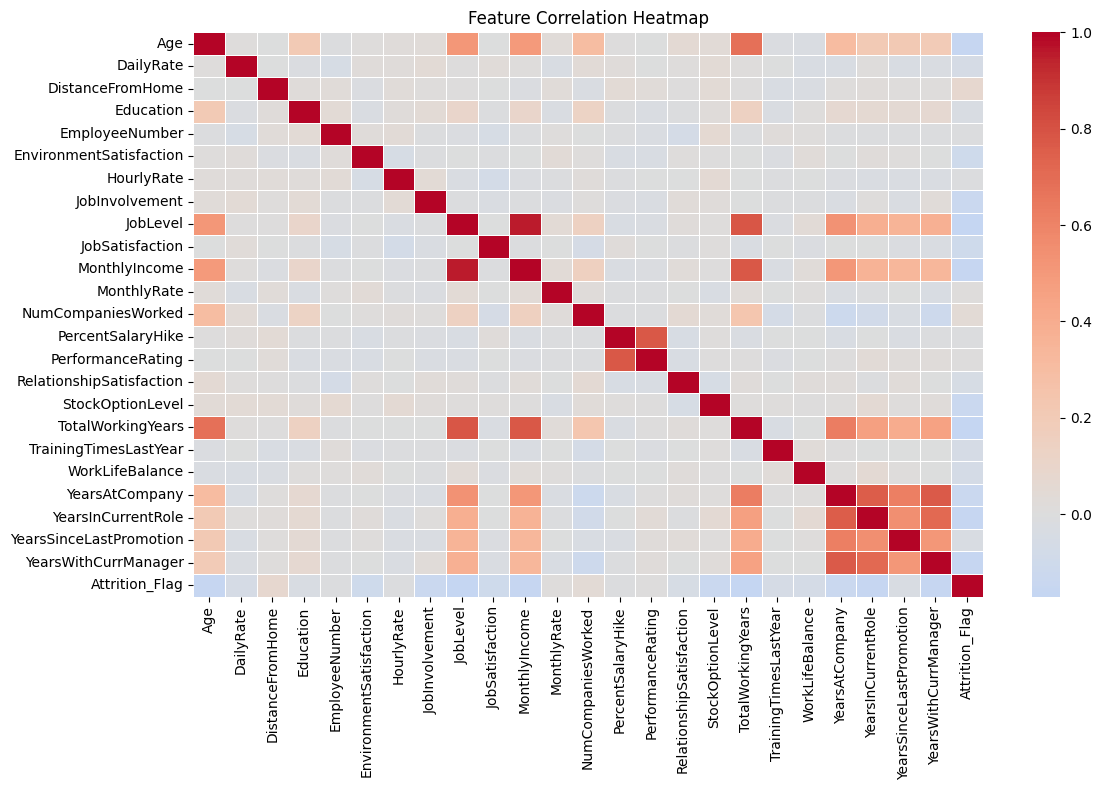

In [13]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, linewidths=0.5, annot=False)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()

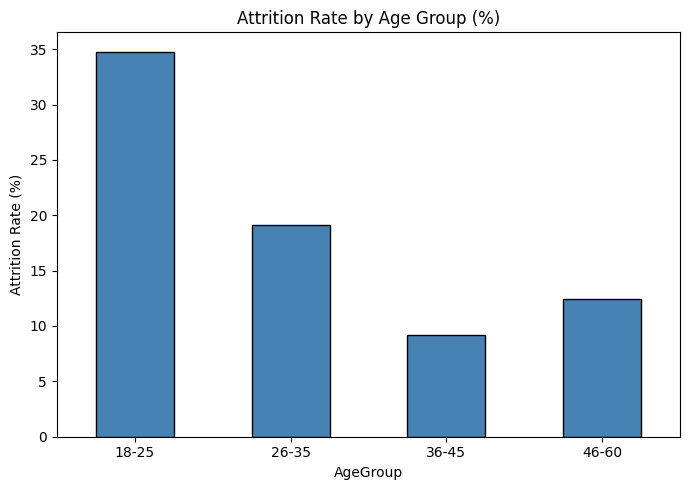

In [17]:
plt.figure(figsize=(7,5))
age_attrition.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Attrition Rate by Age Group (%)')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('age_attrition.png', dpi=150)
plt.show()

In [15]:
#Exporting Clean Dataset
df.to_csv('hr_analytics_clean.csv', index=False)